In [1]:
#  libraries and data

import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, log_loss, mean_poisson_deviance, mean_absolute_error


In [2]:
## data preperation

seasons = [
    "13-14","14-15","15-16","16-17","17-18",
    "18-19","19-20","20-21","21-22","22-23","23-24"
]

dfs = []

for season in seasons:
    file = f"../data/EPL {season}.csv"
    df = pd.read_csv(file)
    df["Season"] = season
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)

In [3]:
## removing none usefull columns

df = full_df.copy()

betting_keywords = [
    "B365","BW","IW","PS","WH","VC","Bb","Div","Time",
    "Max","Avg","AH",">","<","CH","CAH","LB","SJ"
]

cols_to_drop = [
    col for col in df.columns
    if any(keyword in col for keyword in betting_keywords)
]

df = df.drop(columns=cols_to_drop)
# Ensure Date is datetime (important)
df["Date"] = pd.to_datetime(df["Date"])

# Create a stable MatchID based on Season+Date+Teams
df["MatchID"] = (
    df["Season"].astype(str) + "_" +
    df["Date"].dt.strftime("%Y-%m-%d") + "_" +
    df["HomeTeam"].astype(str) + "_" +
    df["AwayTeam"].astype(str)
)


C:\Users\user\AppData\Local\Temp\ipykernel_19284\1752221323.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [4]:
## reshaping df


df = df.copy()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Date"]).sort_values(["Date"], na_position="last")


home = df[[
    "Date","Season","HomeTeam","AwayTeam","FTR",
    "FTHG","FTAG","HTHG","HTAG","HS","HST","HF","HC","HY","HR",
    "AS","AST","AF","AC","AY","AR"
]].copy()

home = home.rename(columns={
    "HomeTeam":"Team", "AwayTeam":"Opponent",
    "FTHG":"GF", "FTAG":"GA",
    "HTHG":"HT_GF", "HTAG":"HT_GA",
    "HS":"Shots", "HST":"SoT", "HF":"Fouls", "HC":"Corners", "HY":"Yellows", "HR":"Reds",
    "AS":"OppShots", "AST":"OppSoT", "AF":"OppFouls", "AC":"OppCorners", "AY":"OppYellows", "AR":"OppReds"
})
home["is_home"] = 1
home["Result"] = home["FTR"].map({"H":"W","D":"D","A":"L"})


away = df[[
    "Date","Season","HomeTeam","AwayTeam","FTR",
    "FTHG","FTAG","HTHG","HTAG","AS","AST","AF","AC","AY","AR",
    "HS","HST","HF","HC","HY","HR"
]].copy()

away = away.rename(columns={
    "AwayTeam":"Team", "HomeTeam":"Opponent",
    "FTAG":"GF", "FTHG":"GA",
    "HTAG":"HT_GF", "HTHG":"HT_GA",
    "AS":"Shots", "AST":"SoT", "AF":"Fouls", "AC":"Corners", "AY":"Yellows", "AR":"Reds",
    "HS":"OppShots", "HST":"OppSoT", "HF":"OppFouls", "HC":"OppCorners", "HY":"OppYellows", "HR":"OppReds"
})
away["is_home"] = 0
away["Result"] = away["FTR"].map({"A":"W","D":"D","H":"L"})


team_df = pd.concat([home, away], ignore_index=True).sort_values(["Team","Date"], na_position="last")
team_df["Points"] = team_df["Result"].map({"W":3, "D":1, "L":0})


In [5]:
team_df = team_df.sort_values(["Date", "Season", "Team", "Opponent", "is_home"]).reset_index(drop=True)

team_df["MatchID"] = (
    team_df["Season"].astype(str) + "_" +
    team_df["Date"].astype(str) + "_" +
    np.where(team_df["is_home"], team_df["Team"], team_df["Opponent"]).astype(str) + "_" +
    np.where(team_df["is_home"], team_df["Opponent"], team_df["Team"]).astype(str)
)


In [6]:
team_df = team_df.sort_values(["Team", "Date"]).reset_index(drop=True)
team_df["GamesPlayed"] = team_df.groupby("Team").cumcount()


In [7]:
##adding columns

team_df = team_df.sort_values(["Team", "Date", "MatchID"]).reset_index(drop=True)

windows = [3, 5, 15]


mean_cols = [
    "GF", "GA", "Points",
    "Shots", "SoT",
    "Corners", "Fouls", "Yellows", "Reds",
    "OppShots", "OppSoT",
    "OppCorners", "OppFouls", "OppYellows", "OppReds",
]

for w in windows:
    for col in mean_cols:
        team_df[f"{col}_roll{w}"] = (
            team_df.groupby("Team")[col]
            .apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )


for w in windows:
    sot_sum = (
        team_df.groupby("Team")["SoT"]
        .apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
        .reset_index(level=0, drop=True)
    )
    shots_sum = (
        team_df.groupby("Team")["Shots"]
        .apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
        .reset_index(level=0, drop=True)
    )
    team_df[f"SoT_pct_roll{w}"] = (sot_sum / shots_sum).replace([np.inf, -np.inf], np.nan).fillna(0)


for w in windows:
    opp_sot_sum = (
        team_df.groupby("Team")["OppSoT"]
        .apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
        .reset_index(level=0, drop=True)
    )
    opp_shots_sum = (
        team_df.groupby("Team")["OppShots"]
        .apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
        .reset_index(level=0, drop=True)
    )
    team_df[f"OppSoT_pct_roll{w}"] = (opp_sot_sum / opp_shots_sum).replace([np.inf, -np.inf], np.nan).fillna(0)


In [8]:
team_df = team_df.fillna(0)


In [9]:
## merge back

home_df = team_df[team_df["is_home"] == 1].copy()
away_df = team_df[team_df["is_home"] == 0].copy()

home_df = home_df.add_suffix("_home")
away_df = away_df.add_suffix("_away")

home_df = home_df.rename(columns={"MatchID_home": "MatchID"})
away_df = away_df.rename(columns={"MatchID_away": "MatchID"})

match_df = home_df.copy()
match_df = match_df.merge(away_df, on="MatchID", how="left")



In [10]:
match_df.columns

Index(['Date_home', 'Season_home', 'Team_home', 'Opponent_home', 'FTR_home',
       'GF_home', 'GA_home', 'HT_GF_home', 'HT_GA_home', 'Shots_home',
       ...
       'OppCorners_roll15_away', 'OppFouls_roll15_away',
       'OppYellows_roll15_away', 'OppReds_roll15_away', 'SoT_pct_roll3_away',
       'SoT_pct_roll5_away', 'SoT_pct_roll15_away', 'OppSoT_pct_roll3_away',
       'OppSoT_pct_roll5_away', 'OppSoT_pct_roll15_away'],
      dtype='object', length=153)

In [11]:
## removing duplicates
match_df["HomeTeam"] = match_df["Team_home"]
match_df["AwayTeam"] = match_df["Team_away"]
match_df["Date"] = match_df["Date_home"]
match_df["Season"] = match_df["Season_home"]
match_df["FTR"] = match_df["FTR_home"]
match_df["Result"] = match_df["Result_home"]
match_df = match_df.drop(columns=[
    'GA_home','Date_home', 'Season_home', 'Team_home','Date_away',
    'Season_away', 'Team_away', 'Opponent_away', 'FTR_away', 
    "Opponent_home","Opponent_away",'HT_GF_home', 'HT_GA_home',
    "is_home_home","is_home_away",'OppShots_home', 'OppSoT_home',
    'OppFouls_home','OppCorners_home','OppYellows_home','OppSoT_away',
    'OppReds_home', 'is_home_home', 'Result_home', 'FTR_home',
    'GA_away', 'HT_GF_away', 'HT_GA_away', 'OppShots_away', 
    'OppFouls_away', 'OppCorners_away', 'Opponent_home', 
    'OppYellows_away','OppReds_away','is_home_away','Result_away',
])


In [15]:
#  preparing for modeling
## time spliting

match_df["Result"] = (
    match_df["Result"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"W": 0, "D": 1, "L": 2, "H": 0, "A": 2})
)

match_df = match_df.sort_values("Date").reset_index(drop=True)

train = match_df[match_df["Date"] < "2021-07-01"]
val   = match_df[(match_df["Date"] >= "2021-07-01") & (match_df["Date"] < "2022-07-01")]
test  = match_df[match_df["Date"] >= "2022-07-01"]

y_train = train["Result"]
y_val   = val["Result"]
y_test  = test["Result"]



In [16]:
## choosing features and target


raw_postmatch = [
    "GF_home","Shots_home","SoT_home","Fouls_home","Corners_home","Yellows_home","Reds_home","Points_home",
    "GF_away","Shots_away","SoT_away","Fouls_away","Corners_away","Yellows_away","Reds_away","Points_away",
    "Result"
]

feature_cols = [c for c in match_df.columns if (
    "roll" in c or
    "pct" in c or
    "GamesPlayed" in c
)]

X_train, X_val, X_test = train[feature_cols], val[feature_cols], test[feature_cols]
y_train, y_val, y_test = train["Result"], val["Result"], test["Result"]


In [17]:
#  training the model

clf = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=800,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

clf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, log_loss

val_pred = clf.predict(X_val)
val_proba = clf.predict_proba(X_val)

print("VAL accuracy:", accuracy_score(y_val, val_pred))
print("VAL logloss:", log_loss(y_val, val_proba))


VAL accuracy: 0.5053763440860215
VAL logloss: 1.1067261368437236


In [ ]:
from sklearn.metrics import accuracy_score

always_home_pred = np.zeros(len(y_val), dtype=int)  # if you encoded H/W as 0
print("Always-Home accuracy:", accuracy_score(y_val, always_home_pred))
## so my model is 20% better than the always home baseline but 19% worse than the best beting odds (by taking the best case of multiple betting website)

Always-Home accuracy: 0.4220430107526882


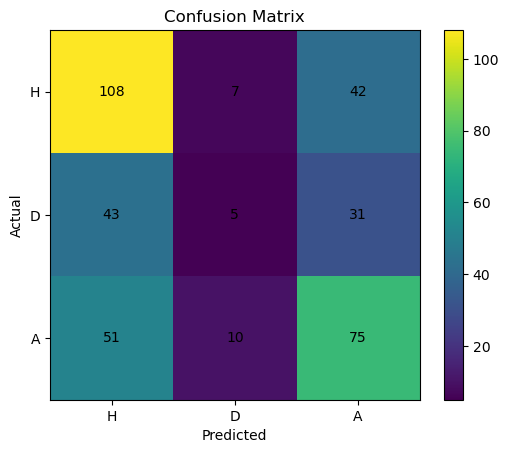

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

val_pred = clf.predict(X_val)

cm = confusion_matrix(y_val, val_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.xticks([0,1,2], ["H","D","A"])
plt.yticks([0,1,2], ["H","D","A"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()


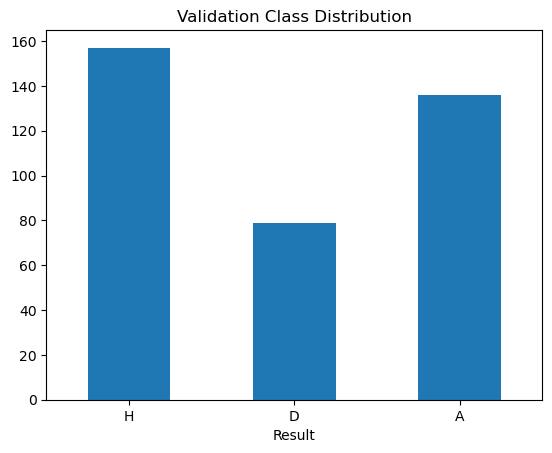

In [ ]:
plt.figure()
y_val.value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1,2], ["H","D","A"], rotation=0)
plt.title("Validation Class Distribution")
plt.show()



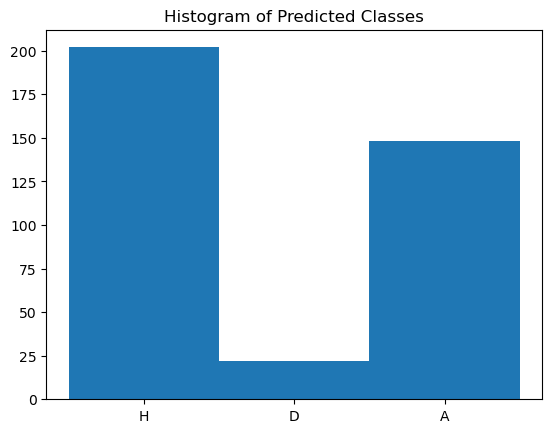

In [24]:
val_pred = clf.predict(X_val)

plt.figure()
plt.hist(val_pred, bins=[-0.5,0.5,1.5,2.5])
plt.xticks([0,1,2], ["H","D","A"])
plt.title("Histogram of Predicted Classes")
plt.show()


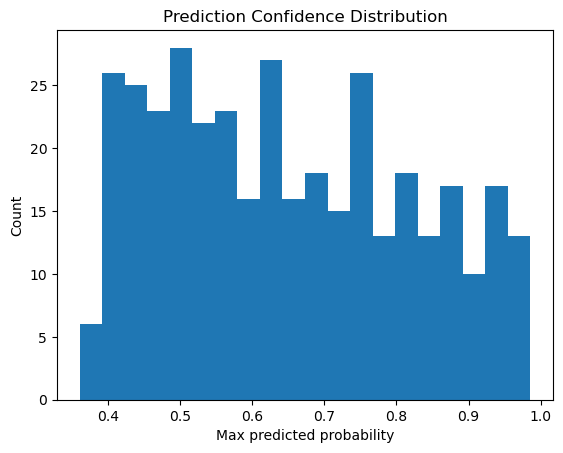

In [26]:
val_proba = clf.predict_proba(X_val)
max_conf = val_proba.max(axis=1)

plt.figure()
plt.hist(max_conf, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Max predicted probability")
plt.ylabel("Count")
plt.show()
